<a href="https://colab.research.google.com/github/sandhyabastola/uci_online_retail_analysis/blob/main/online_retail_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For nicer plots
sns.set(style="whitegrid")
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
#sample 10% rows
df_sample = df.sample(frac=0.1, random_state=42)
df_sample.shape

(54191, 8)

In [5]:
#check for nulls
df_sample.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,149
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,13640
Country,0


In [6]:
#Remove rows with missing CustomerID
df_sample = df_sample.dropna(subset=['CustomerID'])

In [7]:
#Fixed Data Types
df_sample['InvoiceDate'] = pd.to_datetime(df_sample['InvoiceDate'])
df_sample['CustomerID'] = df_sample['CustomerID'].astype(int)
df_sample['InvoiceNo'] = df_sample['InvoiceNo'].astype(str)

In [8]:
#Filters out Return and Free items
df_sample = df_sample[~df_sample['InvoiceNo'].str.startswith('C')]
df_sample = df_sample[(df_sample['Quantity'] > 0) & ( df_sample['UnitPrice'] > 0 )]

In [9]:
# Create Revenue Column
df_sample['Revenue'] = df_sample['Quantity'] * df_sample['UnitPrice']
df_sample.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315,United Kingdom,20.40
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031,United Kingdom,27.80
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031,United Kingdom,2.60
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198,United Kingdom,5.85
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502,United Kingdom,19.90


In [10]:
# compute Top 10 countries by Revenue
top_countries = df_sample.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

/tmp/ipykernel_26292/2324845650.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


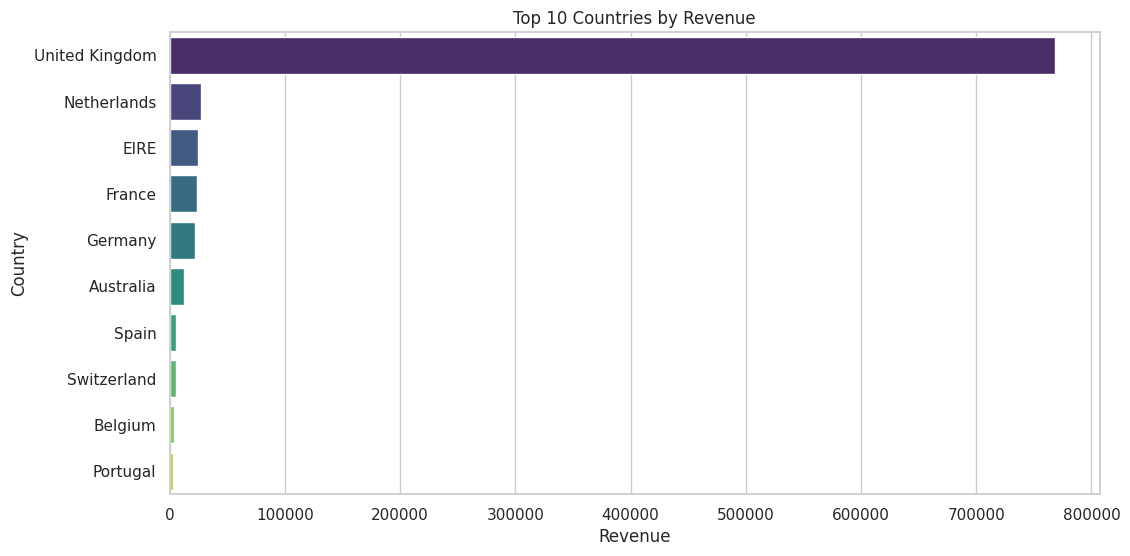

In [11]:
#Plot the results
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()